In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

Загрузим сам датасет

In [4]:
dir = Path.home() / "apartment-price-prediction" / "data" / "processed" / "2023"
file = dir / "moscow_2023.csv"

In [5]:
df = pd.read_csv(file, sep=',')

Проведём первичный анализ

Признаки, которые у нас есть: `Price,Apartment type,Metro station,Minutes to metro,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,Renovation`

In [6]:
pd.set_option('display.float_format', '{:.1f}'.format)

In [7]:
df.describe()

,Price,Minutes to metro,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors
count,16113.0,16113.0,16113.0,16113.0,16113.0,16113.0,16113.0,16113.0
mean,47983477.6,12.5,2.2,81.9,43.9,13.6,9.1,16.4
std,95734362.3,6.8,1.7,78.2,43.6,8.6,8.3,11.3
min,1150000.0,0.0,0.0,6.0,2.0,1.0,1.0,1.0
25%,10200000.0,7.0,1.0,38.8,18.0,8.7,3.0,9.0
50%,15950000.0,12.0,2.0,60.0,31.9,11.3,7.0,14.0
75%,40000000.0,17.0,3.0,93.3,51.0,16.2,13.0,20.0
max,2455020000.0,60.0,12.0,1117.0,566.8,122.0,92.0,97.0


Проанализируем график цена - метро

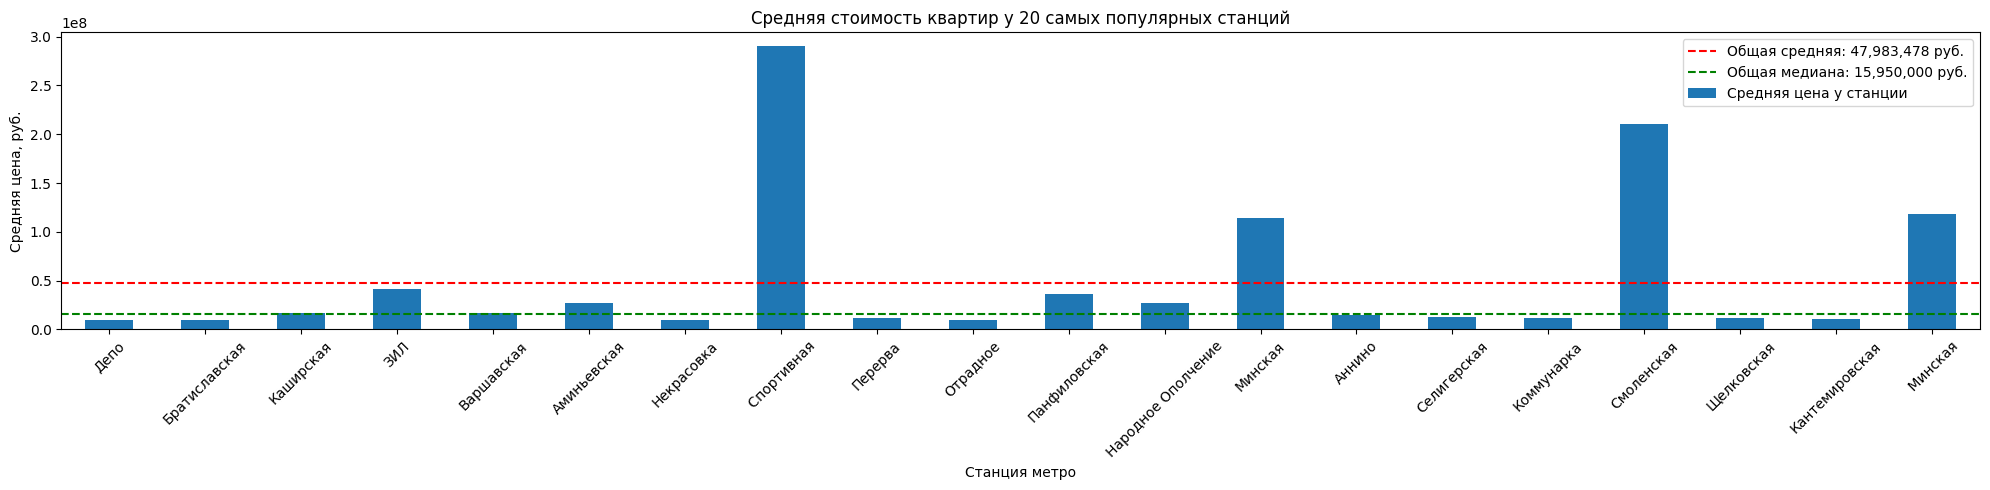

In [ ]:
overall_mean = df['Price'].mean()
overall_median = df['Price'].median()

metro_stats = df.groupby("Metro station").agg(
    avg_price=("Price", "mean"),
    count=("Metro station", "count")
).reset_index()

top20 = metro_stats.nlargest(20, "count")

top20.set_index("Metro station")["avg_price"].plot(
    kind="bar",
    figsize=(20, 5),
    title="Средняя стоимость квартир у 20 самых популярных станций",
    xlabel="Станция метро",
    ylabel="Средняя цена, руб.",
    rot=45,
    label="Средняя цена у станции"
)

plt.axhline(y=overall_mean,
           color='red',
           linestyle='--',
           linewidth=1.5,
           label=f'Общая средняя: {overall_mean:,.0f} руб.')

plt.axhline(
    y=overall_median,
    color='green',
    linestyle='--',
    linewidth=1.5,
    label=f'Общая медиана: {overall_median:,.0f} руб.'
)

plt.tight_layout()

plt.legend()
plt.show()

Проанализируем график цена - минут до метро

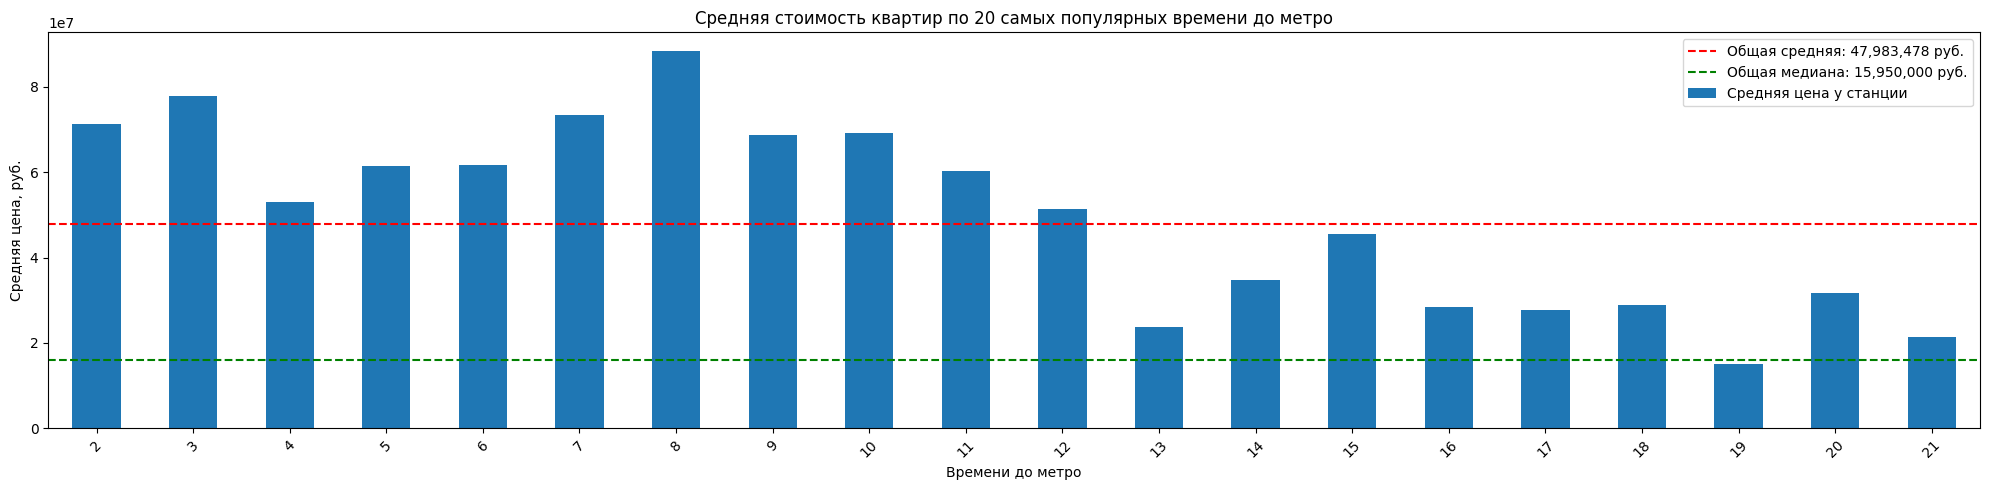

In [ ]:
overall_mean = df['Price'].mean()
overall_median = df['Price'].median()

metro_stats = df.groupby("Minutes to metro").agg(
    avg_price=("Price", "mean"),
    count=("Minutes to metro", "count")
).reset_index()

top20 = metro_stats.nlargest(20, "count")

top20.sort_values("Minutes to metro").astype(int).set_index("Minutes to metro")["avg_price"].plot(
    kind="bar",
    figsize=(20, 5),
    title="Средняя стоимость квартир по 20 самых популярных времени до метро",
    xlabel="Времени до метро",
    ylabel="Средняя цена, руб.",
    rot=45,
    label="Средняя цена у станции"
)

plt.axhline(y=overall_mean,
           color='red',
           linestyle='--',
           linewidth=1.5,
           label=f'Общая средняя: {overall_mean:,.0f} руб.')

plt.axhline(
    y=overall_median,
    color='green',
    linestyle='--',
    linewidth=1.5,
    label=f'Общая медиана: {overall_median:,.0f} руб.'
)

plt.tight_layout()

plt.legend()
plt.show()

Проанализируем график цена - тип постройки

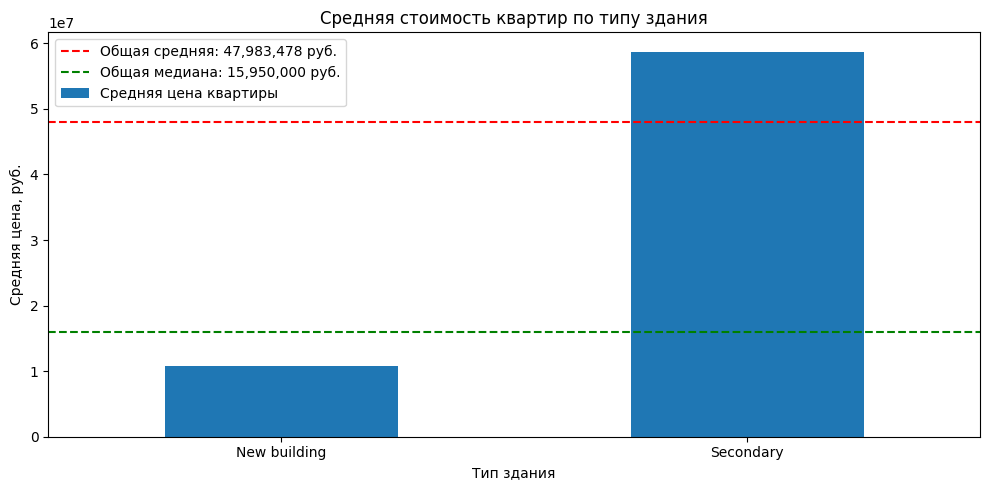

In [ ]:
overall_mean = df['Price'].mean()
overall_median = df['Price'].median()

apart_stats = df.groupby("Apartment type").agg(
    avg_price=("Price", "mean"),
    count=("Apartment type", "count")
).reset_index()

apart_stats.set_index("Apartment type")["avg_price"].plot(
    kind="bar",
    figsize=(10, 5),
    title="Средняя стоимость квартир по типу здания",
    xlabel="Тип здания",
    ylabel="Средняя цена, руб.",
    rot=0,
    label="Средняя цена квартиры"
)

plt.axhline(y=overall_mean,
           color='red',
           linestyle='--',
           linewidth=1.5,
           label=f'Общая средняя: {overall_mean:,.0f} руб.')

plt.axhline(
    y=overall_median,
    color='green',
    linestyle='--',
    linewidth=1.5,
    label=f'Общая медиана: {overall_median:,.0f} руб.'
)

plt.tight_layout()

plt.legend()
plt.show()

In [ ]:
df["Apartment type"].value_counts()

Apartment type
Secondary       12500
New building     3613
Name: count, dtype: int64

Проанализируем, почему средняя стоимость новостроек НИЖЕ общей медианы (не то чтобы уже средней стоимости вторичек)

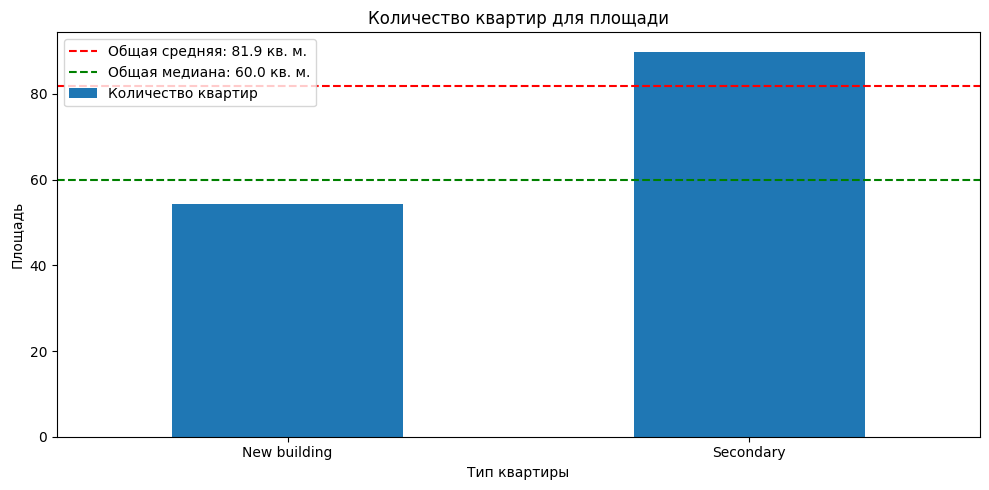

In [63]:
overall_mean = df['Area'].mean()
overall_median = df['Area'].median()

apart_stats = df.groupby("Apartment type").agg(
    area=("Area", "mean"),
    apart_count=("Apartment type", "count")
).reset_index()

apart_stats.set_index("Apartment type")["area"].plot(
    kind="bar",
    figsize=(10, 5),
    title="Количество квартир для площади",
    xlabel="Тип квартиры",
    ylabel="Площадь",
    rot=0,
    label="Количество квартир"
)

plt.axhline(y=overall_mean,
           color='red',
           linestyle='--',
           linewidth=1.5,
           label=f'Общая средняя: {overall_mean:,.1f} кв. м.')

plt.axhline(
    y=overall_median,
    color='green',
    linestyle='--',
    linewidth=1.5,
    label=f'Общая медиана: {overall_median:,.1f} кв. м.'
)

plt.tight_layout()

plt.legend()
plt.show()

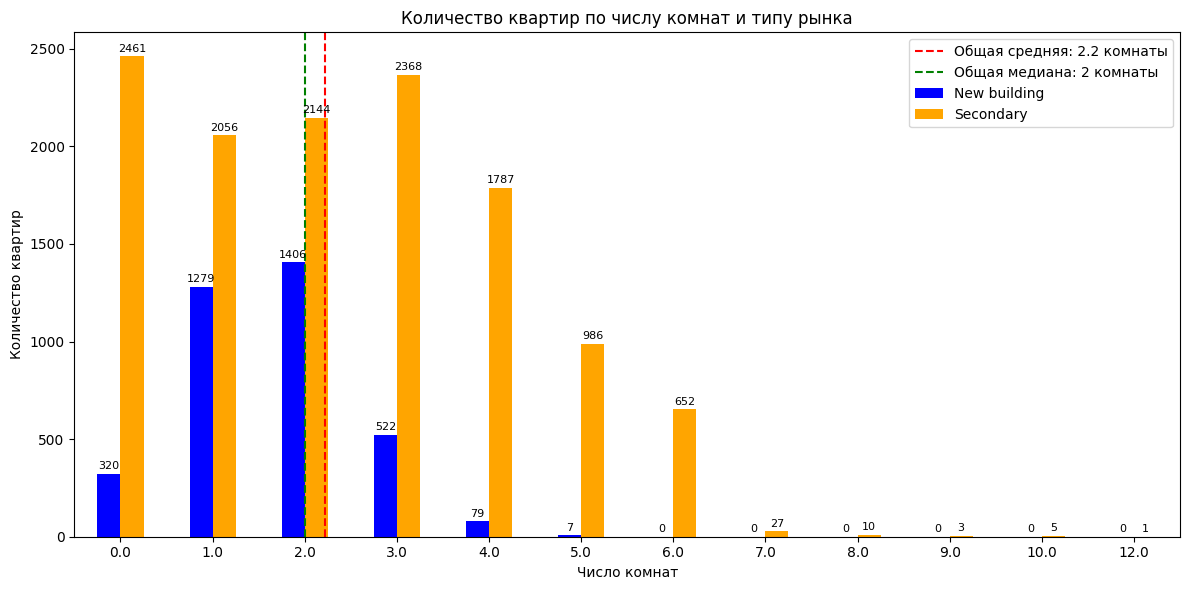

In [62]:
overall_mean = df['Number of rooms'].mean()
overall_median = df['Number of rooms'].median()

market_counts = df.groupby(['Number of rooms', 'Apartment type']).size().unstack(fill_value=0)

ax = market_counts.plot(
    kind='bar',
    figsize=(12, 6),
    rot=0,
    color=['blue', 'orange'],
    title='Количество квартир по числу комнат и типу рынка',
    xlabel='Число комнат',
    ylabel='Количество квартир'
)

for container in ax.containers:
    ax.bar_label(container, padding=2, fontsize=8)

plt.axvline(x=overall_mean,
           color='red',
           linestyle='--',
           linewidth=1.5,
           label=f'Общая средняя: {overall_mean:,.1f} комнаты')

plt.axvline(
    x=overall_median,
    color='green',
    linestyle='--',
    linewidth=1.5,
    label=f'Общая медиана: {overall_median:,.0f} комнаты'
)

plt.tight_layout()

plt.legend()
plt.show()

Тип ремонта от лучшего к худшему:
- 1. Designer
- 2. European-style
- 3. Cosmetic
- 4. Without

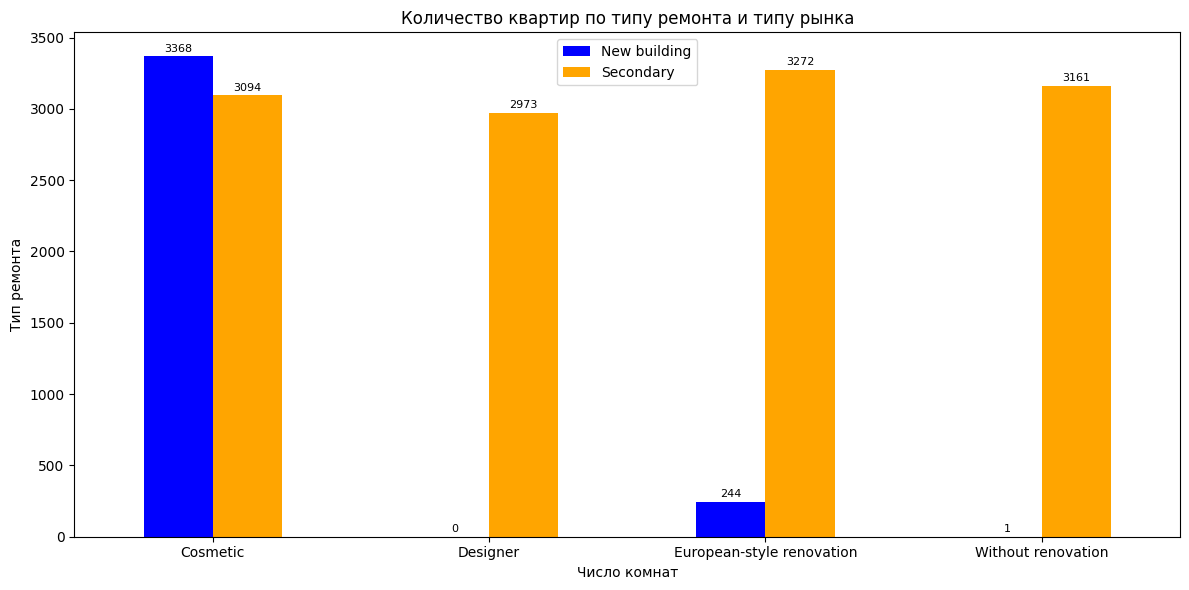

In [61]:
market_counts = df.groupby(['Renovation', 'Apartment type']).size().unstack(fill_value=0)

ax = market_counts.plot(
    kind='bar',
    figsize=(12, 6),
    rot=0,
    color=['blue', 'orange'],
    title='Количество квартир по типу ремонта и типу рынка',
    xlabel='Число комнат',
    ylabel='Тип ремонта'
)

for container in ax.containers:
    ax.bar_label(container, padding=2, fontsize=8)


plt.tight_layout()

plt.legend()
plt.show()